## REDUCCIÓN DE COMPONENTES PRINCIPALES
CESNET TIME SERIES 24 - AGGREGATION 10 MINUTE
- FPCA 2D más clustering(Functional K-Means, DBSCAN y HDBSCAN)
- FPCA 3D más clustering(Functional K-Means, DBSCAN y HDBSCAN)

In [1]:
# IMPORTS, FUNCIONES Y DIRECTORIOS

# IMPORTS
import pandas as pd
import numpy as np
import os
import tqdm
from scipy.io import savemat
import matplotlib.pyplot as plt
import ast  # Para convertir strings que representan listas a listas reales
import warnings
warnings.filterwarnings("ignore")
import skfda
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.ml.clustering import KMeans
from datetime import datetime
from datetime import date
from skfda.representation.basis import BSplineBasis, FourierBasis
from skfda.misc.metrics import lp_distance
from skfda.representation.grid import FDataGrid
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from sklearn.metrics import silhouette_score
from skfda.misc.metrics import LpDistance

# FUNCIONES
# Ajustar el eje X para mostrar fechas en lugar de segundos Unix
# a) Convertir los valores del eje x (segundos Unix) a un formato numérico
# que Matplotlib pueda interpretar como fecha (días desde el año 0)
# Esto se hace usando la función personalizada UnixConverter.
# Como FDataGrid usa los segundos directamente, la conversión
# debe hacerse en el formateador o usar una aproximación.

# En Matplotlib, `ax.xaxis.set_major_formatter()` es lo que necesitas.
# Usaremos un formateador que convierta los segundos Unix a objetos datetime.
def unix_to_date_formatter(unix_timestamp, pos):
    """
    Formateador de Matplotlib para convertir segundos Unix a fecha.
    """
    # Se añade un pequeño offset si Matplotlib lo requiere, pero generalmente
    # epoch2num es el conversor más limpio para Matplotlib.
    return pd.to_datetime(unix_timestamp, unit='s').strftime('%Y-%m-%d')
    # O para una representación de solo día/mes:
    # return pd.to_datetime(unix_timestamp, unit='s').strftime('%d %b')


def aplicar_mu_law(df, mu=255, col_time="time"):
    def transformar_columna(x):
        x_max = x.abs().max()
        if x_max == 0:
            return x

        x_norm = x / x_max
        x_mu = np.sign(x_norm) * (np.log(1 + mu * np.abs(x_norm)) / np.log(1 + mu))
        return x_mu

    # Separar time
    time = df[col_time]
    data = df.drop(columns=[col_time])

    # Aplicar Mu-Law solo a las señales
    data_mu = data.apply(transformar_columna)

    # Volver a unir time
    data_mu[col_time] = time

    return data_mu


def t_to_datetime_info(t_norm):
    """
    Convierte t ∈ [0,1] a día, hora y minuto reales
    """
    minutes_per_week = 7 * 24 * 60

    total_minutes = t_norm * minutes_per_week

    day_idx = int(total_minutes // (24 * 60))
    day_idx = min(day_idx, 6)  # seguridad numérica

    minutes_in_day = total_minutes % (24 * 60)
    hour = int(minutes_in_day // 60)
    minute = int(minutes_in_day % 60)

    days = ["Lunes", "Martes", "Miércoles",
            "Jueves", "Viernes", "Sábado", "Domingo"]

    return days[day_idx], hour, minute


def t_to_original_index(t_norm, n_points=1008):
    """
    Mapea t ∈ [0,1] al índice original más cercano
    """
    idx = int(round(t_norm * (n_points - 1)))
    return max(0, min(idx, n_points - 1))


def parse_week_column(col_name):
    """
    Ejemplo: 'n_flows_0_41_2023'
    → variable='n_flows_0', week=41, year=2023
    """
    parts = col_name.split("_")
    year = int(parts[-1])
    week = int(parts[-2])
    variable = "_".join(parts[:-2])
    return variable, week, year

def get_week_mask(df_ts, week, year):
    return (
        (df_ts.index.isocalendar().week == week) &
        (df_ts.index.isocalendar().year == year)
    )


# DIRECTORIOS
DATASET_PATH = r"C:\Users\itsal\Desktop\MASTER\TFM\CESNET\CESNET_TimeSeries24"

IP_ADDRESSES_SAMPLE = os.path.join(DATASET_PATH, "ip_addresses_sample")
INSTITUTIONS = os.path.join(DATASET_PATH, "institutions")
INSTITUTION_SUBNETS = os.path.join(DATASET_PATH, "institution_subnets")
##IP_ADDRESSES_FULL = os.path.join(DATASET_PATH, "ip_addresses_full")


TIMES_10_MINUTES = os.path.join(DATASET_PATH, "times", "times_10_minutes.csv")
TIMES_1_HOUR = os.path.join(DATASET_PATH, "times", "times_1_hour.csv")
TIMES_1_DAY = os.path.join(DATASET_PATH, "times", "times_1_day.csv")


# !!!!!!!!!!!!!! INSTITUTIONS !!!!!!!!!!!!!! <- se puede cambiar
agg_1_day_path = os.path.join(INSTITUTIONS, "agg_1_day")
agg_1_hour_path = os.path.join(INSTITUTIONS, "agg_1_hour")
agg_10_minutes_path = os.path.join(INSTITUTIONS, "agg_10_minutes_filtrado")
# !!!!!!!!!!!!!! INSTITUTIONS !!!!!!!!!!!!!! <- se puede cambiar

In [2]:
# VARIABLES PARA USAR
file_path = os.path.join(agg_10_minutes_path, os.listdir(agg_10_minutes_path)[0])
df_TS24 = pd.read_csv(file_path)
print(df_TS24.columns[1:].tolist())


['n_flows', 'n_packets', 'n_bytes', 'sum_n_dest_asn', 'average_n_dest_asn', 'std_n_dest_asn', 'sum_n_dest_ports', 'average_n_dest_ports', 'std_n_dest_ports', 'sum_n_dest_ip', 'average_n_dest_ip', 'std_n_dest_ip', 'tcp_udp_ratio_packets', 'tcp_udp_ratio_bytes', 'dir_ratio_packets', 'dir_ratio_bytes', 'avg_duration', 'avg_ttl']


In [3]:
# INSITUCIONES DISPONIBLES
csv_files = [
    f for f in os.listdir(agg_10_minutes_path)
    if f.endswith(".csv")
]

print(csv_files)



['0.csv', '10.csv', '108.csv', '109.csv', '113.csv', '139.csv', '145.csv', '147.csv', '161.csv', '175.csv', '198.csv', '216.csv', '223.csv', '224.csv', '23.csv', '230.csv', '235.csv', '243.csv', '244.csv', '249.csv', '34.csv', '42.csv', '48.csv', '50.csv', '53.csv', '55.csv', '56.csv', '57.csv', '59.csv', '62.csv', '68.csv', '69.csv', '70.csv', '80.csv', '86.csv', '93.csv']


In [4]:
# ELECCIÓN DE VARIABLE E INSTITUCIÓN
variable = "n_packets"
institucion = "0.csv"

In [5]:
# FICHERO Y COMPANDING
# Rutas
fpath = os.path.join(agg_10_minutes_path, institucion)

# Leer mapping id_time → time
times_df = pd.read_csv(TIMES_10_MINUTES)

# Rutas
fpath = os.path.join(agg_10_minutes_path, institucion)

# Leer mapping id_time → time
times_df = pd.read_csv(TIMES_10_MINUTES)

# Leer solo el CSV que nos interesa
df_TS24_insititucion = pd.read_csv(fpath)

# Comprobar que la variable existe
if variable not in df_TS24_insititucion.columns:
    raise ValueError(f"La variable '{variable}' no existe en {institucion}")

# Merge para sustituir id_time por time
df_TS24_insititucion = (
    df_TS24_insititucion.merge(times_df, on="id_time", how="left")
      .drop(columns=["id_time"])
)
# Renombrar la columna como n_flows_0
new_col = f"{variable}_{institucion.replace('.csv','')}"

df_TS24_insititucion = df_TS24_insititucion[["time", variable]].rename(columns={variable: new_col})

# Convertir time a datetime y eliminar zona horaria
df_TS24_insititucion["time"] = pd.to_datetime(df_TS24_insititucion["time"], utc=True).dt.tz_localize(None)


# COMPANDING Y PASAR DE DATOS ESCALARES A FUNCIONALES (FOURIER)
df_TS24_companded = aplicar_mu_law(df_TS24_insititucion)
cols = ['time'] + [c for c in df_TS24_companded.columns if c != 'time']
df_TS24_companded = df_TS24_companded[cols]

df_TS24_companded

,time,n_packets_0
0,2023-10-09 00:03:49,0.556011
1,2023-10-09 00:13:49,0.612719
2,2023-10-09 00:23:49,0.529257
3,2023-10-09 00:33:49,0.545362
4,2023-10-09 00:43:49,0.550940
...,...,...
40293,2024-07-14 21:10:52,0.665485
40294,2024-07-14 21:20:52,0.689312
40295,2024-07-14 21:30:52,0.732208
40296,2024-07-14 21:40:52,0.653425


In [6]:
# SEMANAS DISPONIBLES
groups_week = dict(
    tuple(
        df_TS24_companded.groupby(
            [
                df_TS24_companded["time"].dt.isocalendar().year,
                df_TS24_companded["time"].dt.isocalendar().week,
            ]
        )
    )
)

# Semanas disponibles (AÑO, SEMANA)
semanas_disponibles = [(int(a), int(b)) for a, b in groups_week]
print(semanas_disponibles)


[(2023, 41), (2023, 42), (2023, 43), (2023, 44), (2023, 45), (2023, 46), (2023, 47), (2023, 48), (2023, 49), (2023, 50), (2023, 51), (2023, 52), (2024, 1), (2024, 2), (2024, 3), (2024, 4), (2024, 5), (2024, 6), (2024, 7), (2024, 8), (2024, 9), (2024, 10), (2024, 11), (2024, 12), (2024, 13), (2024, 14), (2024, 15), (2024, 16), (2024, 17), (2024, 18), (2024, 19), (2024, 20), (2024, 21), (2024, 22), (2024, 23), (2024, 24), (2024, 25), (2024, 26), (2024, 27), (2024, 28)]


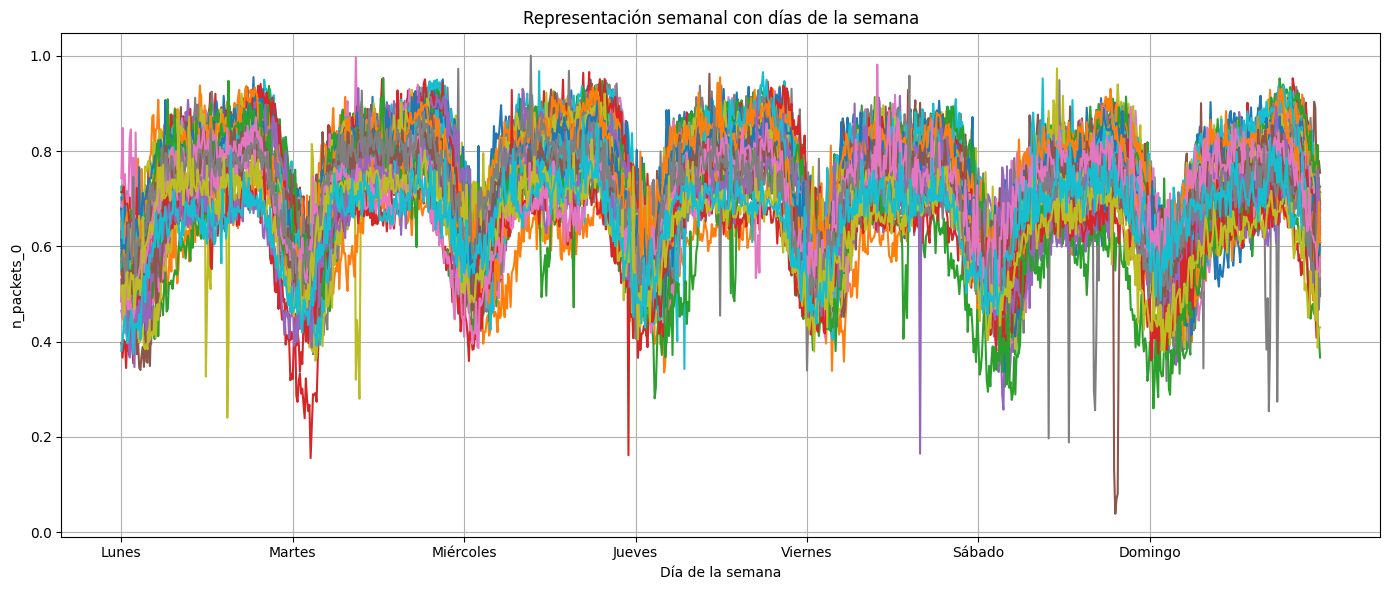

,n_packets_0_41_2023,n_packets_0_42_2023,n_packets_0_43_2023,n_packets_0_44_2023,n_packets_0_45_2023,n_packets_0_46_2023,n_packets_0_47_2023,n_packets_0_48_2023,n_packets_0_49_2023,n_packets_0_50_2023,...,n_packets_0_19_2024,n_packets_0_20_2024,n_packets_0_21_2024,n_packets_0_22_2024,n_packets_0_23_2024,n_packets_0_24_2024,n_packets_0_25_2024,n_packets_0_26_2024,n_packets_0_27_2024,n_packets_0_28_2024
0,0.556011,0.609480,0.549427,0.678533,0.668763,0.682168,0.742954,0.614079,0.723969,0.725587,...,0.613651,0.543080,0.582522,0.397326,0.464661,0.484525,0.496956,0.566050,0.495936,0.380174
1,0.612719,0.728652,0.541554,0.664449,0.613760,0.653342,0.848537,0.652039,0.668322,0.695635,...,0.573658,0.530750,0.560446,0.366353,0.451885,0.554196,0.446733,0.582805,0.518806,0.400646
2,0.529257,0.616380,0.576991,0.660761,0.707351,0.686775,0.684819,0.587157,0.660500,0.689444,...,0.602296,0.591883,0.549168,0.403835,0.474241,0.510764,0.498204,0.574859,0.429805,0.433742
3,0.545362,0.566197,0.541016,0.685284,0.734166,0.634592,0.730025,0.523346,0.668982,0.685812,...,0.582563,0.568739,0.499957,0.399608,0.511719,0.531607,0.417852,0.546741,0.519970,0.453899
4,0.550940,0.655896,0.598077,0.630269,0.651545,0.624568,0.673699,0.574771,0.669047,0.715490,...,0.616952,0.540195,0.480850,0.344491,0.417446,0.486341,0.577047,0.582083,0.515802,0.422408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,0.647799,0.624615,NaN,0.735795,0.775653,0.890397,0.663877,0.731800,0.752083,0.769259,...,0.596415,0.584218,0.496765,0.476288,0.523606,0.526707,0.609221,0.542120,0.444748,NaN
1004,0.589268,0.531128,NaN,0.677874,0.717443,0.754433,0.625345,0.741366,0.781181,0.766703,...,0.600382,0.580584,0.511536,0.408256,0.555796,0.518597,0.589952,0.520790,0.548486,NaN
1005,0.646395,0.602045,NaN,0.666297,0.721264,0.776338,0.690429,0.755357,0.732735,0.736264,...,0.573627,0.601670,0.438735,0.489901,0.501939,0.495866,0.535528,0.543806,0.387065,NaN
1006,0.609552,0.560975,NaN,0.742872,0.666440,0.779598,0.622374,0.696593,0.718102,0.692986,...,0.579675,0.693626,0.410448,0.526151,0.550174,0.581515,0.515986,0.466854,0.425893,NaN


In [7]:
# SEPARAR DF EN SEMANAS 
# Extraer año ISO y semana ISO
iso = df_TS24_companded['time'].dt.isocalendar()
df_TS24_companded['iso_year'] = iso.year
df_TS24_companded['iso_week'] = iso.week

# Nombre de la segunda columna
second_col = df_TS24_companded.columns[1]

# Diccionario para columnas
weekly_data = {}

# Agrupar por año ISO y semana ISO
for (year, week), group in df_TS24_companded.groupby(['iso_year', 'iso_week']):
    col_name = f"{second_col}_{int(week):02d}_{int(year)}"
    weekly_data[col_name] = group[second_col].reset_index(drop=True)

# Crear DataFrame final
df_weeks = pd.DataFrame(weekly_data)


# ---------------------------
# Crear eje X en horas y días
# ---------------------------
n_time = df_weeks.shape[0]
minutes_per_step = 10
x_hours = np.arange(n_time) * minutes_per_step / 60  # horas acumuladas

days = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
ticks = np.arange(0, 7*24, 24)  # cada 24 horas


plt.figure(figsize=(14, 6))

for col in df_weeks.columns:
    plt.plot(x_hours, df_weeks[col], label=col)

plt.xlabel("Día de la semana")
plt.ylabel(df_TS24_companded.columns[1])
plt.title("Representación semanal con días de la semana")

plt.xticks(ticks, days)
plt.grid(True)
plt.tight_layout()
plt.show()


df_weeks


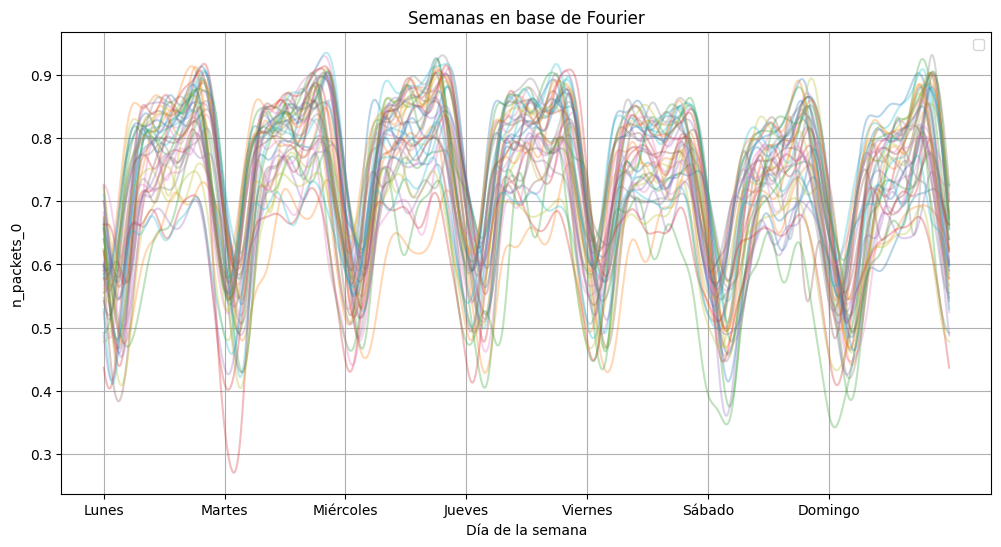

In [8]:
# PASAR A DATOS FUNCIONALES Y REPRESENTACION

# ---------------------------
# 1️⃣ Limpiar DataFrame
# ---------------------------
df_weeks_clean = (
    df_weeks
    .interpolate(axis=0, limit_direction='both')
    .fillna(method='bfill')
    .fillna(method='ffill')
)

# ---------------------------
# 2️⃣ Crear base de Fourier
# ---------------------------
n_time = df_weeks_clean.shape[0]   # puntos por semana
t = np.linspace(0, 1, n_time)      # dominio normalizado
n_basis = 70                        # AJUSTADO CON MIRANDO EL CODO DEL MSE

basis = FourierBasis(domain_range=(0, 1), n_basis=n_basis)

fd = FDataGrid(
    data_matrix=df_weeks_clean.T.values,
    grid_points=t
)

fd_fourier = fd.to_basis(basis)

# ---------------------------
# 3️⃣ Evaluar funciones en la rejilla temporal
# ---------------------------
X = fd_fourier(t).squeeze()   # shape: (n_semanas, n_time)

# ---------------------------
# 4️⃣ Crear eje x en horas
# ---------------------------
minutes_per_step = 10
x_hours = np.arange(n_time) * minutes_per_step / 60  # tiempo en horas

# Etiquetas de los días
days = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
hours_per_day = 24
ticks = np.arange(0, 7*24, 24)  # 0, 24, 48, 72, 96, 120, 144 → 7 ticks

# ---------------------------
# 5️⃣ Plot de semanas superpuestas
# ---------------------------
plt.figure(figsize=(12, 6))

for week_curve in X:
    plt.plot(x_hours, week_curve, alpha=0.3)  # todas las semanas semi-transparente

plt.title("Semanas en base de Fourier")
plt.xlabel("Día de la semana")
plt.ylabel(df_TS24_companded.columns[1])
plt.xticks(ticks, days)
plt.grid(True)
plt.legend()
plt.show()


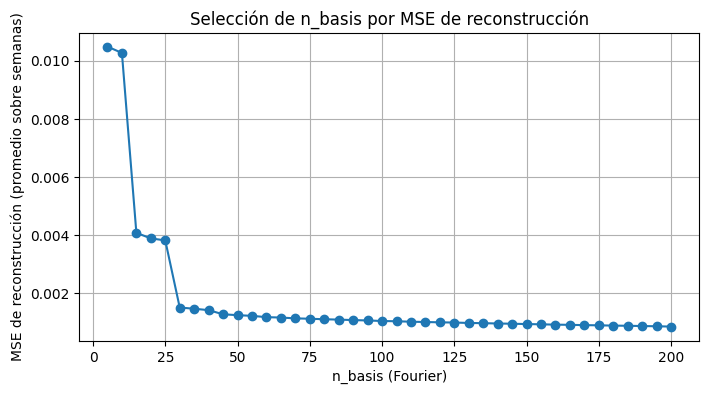

In [9]:
# ELECCIÓN DEL N_BASIS
# ---------------------------
# 6️⃣ Selección de n_basis por MSE de reconstrucción
# ---------------------------

# parámetros para búsqueda
n_pts = len(t)
max_basis = min(200, n_pts)   # límite razonable
min_basis = 5
step = 5

n_list = list(range(min_basis, max_basis + 1, step))
mses = []

# datos originales en grilla
orig = fd.data_matrix[..., 0]   # shape: (n_semanas, n_time)

for n in n_list:
    basis = FourierBasis(domain_range=(0, 1), n_basis=n)
    try:
        fd_basis = fd.to_basis(basis)   # proyección a base
    except Exception as e:
        print(f"Error con n_basis={n}: {e}")
        mses.append(np.nan)
        continue

    # reconstrucción en la grilla original
    fd_rec = fd_basis.to_grid(grid_points=t)
    rec = fd_rec.data_matrix[..., 0]

    # MSE por semana y promedio
    mse_per_sample = ((orig - rec) ** 2).mean(axis=1)
    mses.append(mse_per_sample.mean())

# ---------------------------
# 7️⃣ Plot MSE vs n_basis
# ---------------------------
plt.figure(figsize=(8, 4))
plt.plot(n_list, mses, marker='o')
plt.xlabel('n_basis (Fourier)')
plt.ylabel('MSE de reconstrucción (promedio sobre semanas)')
plt.title('Selección de n_basis por MSE de reconstrucción')
plt.grid(True)
plt.show()


FUNCTIONAL PRINCIPAL COMPONENT ANALISIS

Número de componentes que retienen el 99% de la varianza: 19


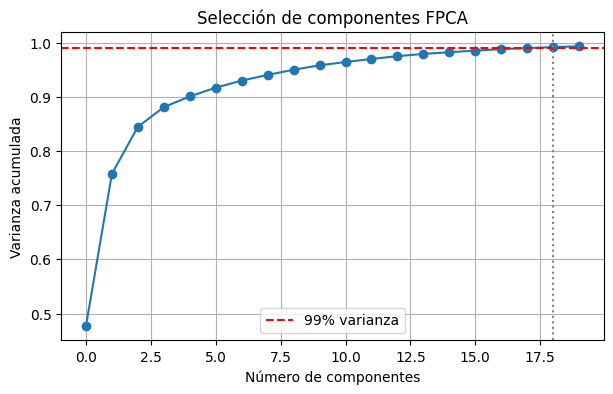

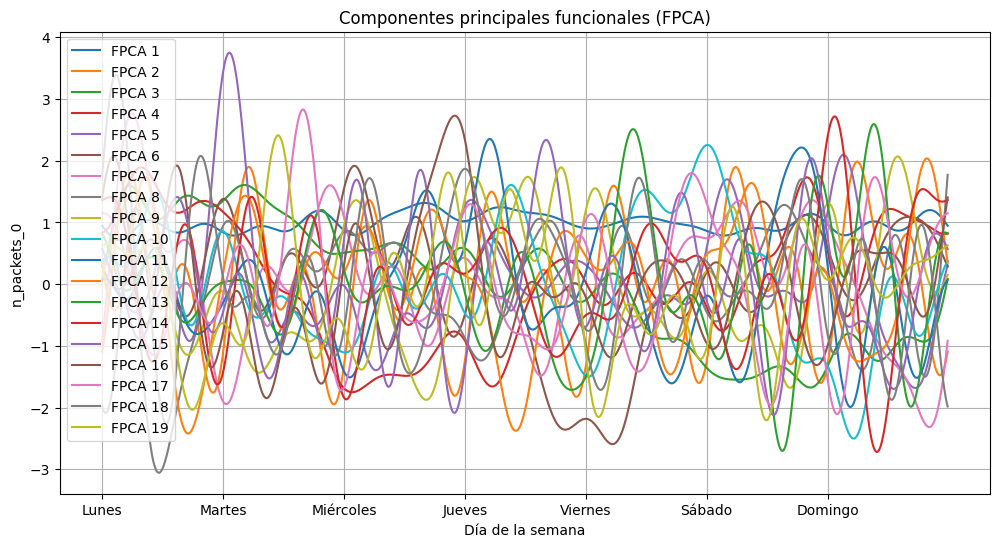

In [13]:
# FUNCTIONAL PRINCIPAL COMPONENT ANALISIS
import numpy as np
import matplotlib.pyplot as plt
from skfda.representation.basis import FourierBasis
from skfda.representation.grid import FDataGrid
from skfda.preprocessing.dim_reduction import FPCA



# ---------------------------
# 1️⃣ Limpiar DataFrame
# ---------------------------
df_weeks_clean = (
    df_weeks
    .interpolate(axis=0, limit_direction='both')
    .fillna(method='bfill')
    .fillna(method='ffill')
)

# ---------------------------
# 2️⃣ Crear base de Fourier
# ---------------------------
n_time = df_weeks_clean.shape[0]   # puntos por semana
t = np.linspace(0, 1, n_time)      # dominio normalizado

n_basis = 30  # elegido previamente por el codo del MSE
basis = FourierBasis(domain_range=(0, 1), n_basis=n_basis)

fd = FDataGrid(
    data_matrix=df_weeks_clean.T.values,  # semanas × tiempo
    grid_points=t
)

fd_fourier = fd.to_basis(basis)

# ---------------------------
# 3️⃣ Eje temporal en horas
# ---------------------------
minutes_per_step = 10
x_hours = np.arange(n_time) * minutes_per_step / 60

days = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
ticks = np.arange(0, 7 * 24, 24)

# ---------------------------
# 4️⃣ FPCA inicial (muchas componentes)
# ---------------------------
max_components = min(20, fd_fourier.n_samples)

fpca_full = FPCA(
    n_components=max_components,
    centering=True
)

fpca_full.fit(fd_fourier)

explained_variance = fpca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# ---------------------------
# 5️⃣ Selección automática (99% varianza)
# ---------------------------
threshold = 0.99
n_components_99 = np.searchsorted(cumulative_variance, threshold) + 1

print(f"Número de componentes que retienen el 99% de la varianza: {n_components_99}")

# ---------------------------
# 6️⃣ FPCA final con n_components óptimo
# ---------------------------
fpca = FPCA(
    n_components=n_components_99,
    centering=True
)

fpca.fit(fd_fourier)

scores = fpca.transform(fd_fourier)

# ---------------------------
# 7️⃣ Plot varianza explicada
# ---------------------------
plt.figure(figsize=(7, 4))
plt.plot(cumulative_variance, marker='o')
plt.axhline(0.99, color='red', linestyle='--', label='99% varianza')
plt.axvline(n_components_99 - 1, color='gray', linestyle=':')
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("Selección de componentes FPCA")
plt.grid(True)
plt.legend()

# Guardar en PDF
plt.savefig(
    "fpca_varianza_acumulada.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


# ---------------------------
# 8️⃣ Componentes principales funcionales
# ---------------------------
pc_functions = fpca.components_

plt.figure(figsize=(12, 6))

for i in range(n_components_99):
    plt.plot(
        x_hours,
        pc_functions[i](t).squeeze(),
        label=f"FPCA {i+1}"
    )

plt.title("Componentes principales funcionales (FPCA)")
plt.xlabel("Día de la semana")
plt.ylabel(df_TS24_companded.columns[1])
plt.xticks(ticks, days)
plt.grid(True)
plt.legend()

# Guardar en PDF
plt.savefig(
    "fpca_componentes_funcionales.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [12]:
# ---------------------------
# Varianza explicada por componente
# ---------------------------
import pandas as pd

variance_table = pd.DataFrame({
    "Componente": np.arange(1, len(explained_variance) + 1),
    "Varianza explicada (%)": explained_variance * 100,
    "Varianza acumulada (%)": cumulative_variance * 100
})

# Mostrar tabla
print(variance_table.round(2))

    Componente  Varianza explicada (%)  Varianza acumulada (%)
0            1                   47.66                   47.66
1            2                   28.13                   75.79
2            3                    8.67                   84.46
3            4                    3.64                   88.10
4            5                    1.99                   90.09
5            6                    1.61                   91.70
6            7                    1.30                   93.00
7            8                    1.05                   94.05
8            9                    0.95                   95.00
9           10                    0.82                   95.83
10          11                    0.61                   96.43
11          12                    0.57                   97.00
12          13                    0.51                   97.51
13          14                    0.41                   97.92
14          15                    0.32                 

In [15]:
# ============================================================
# CLUSTERING FPCA 2D
# Cada punto → una semana
# Cercanía → semanas con patrones temporales similares
# Clusters → tipos de comportamiento semanal
# OUTPUT: PDFs de los plots
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import hdbscan

# ============================================================
# 1. SELECCIÓN AUTOMÁTICA DE K (SILHOUETTE)
# ============================================================

X = scores[:, :2]  # FPCA1 y FPCA2

silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    km_tmp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    labels_tmp = km_tmp.fit_predict(X)
    silhouette_scores.append(
        silhouette_score(X, labels_tmp)
    )

n_clusters = K_range[np.argmax(silhouette_scores)]
print(f"Número óptimo de clusters (Silhouette): {n_clusters}")

# ============================================================
# 2. K-MEANS
# ============================================================

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=20
)

labels_km = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

x_line = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
coef = np.polyfit(X[:, 0], X[:, 1], 1)
y_line = coef[0] * x_line + coef[1]

plt.figure(figsize=(8, 6))
colors = plt.cm.tab10.colors

for k in range(n_clusters):
    plt.scatter(
        X[labels_km == k, 0],
        X[labels_km == k, 1],
        color=colors[k],
        alpha=0.8,
        label=f"Cluster {k+1}"
    )

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="x",
    s=200,
    color="black",
    linewidths=3,
    label="Centroides"
)

plt.plot(x_line, y_line, color="steelblue", alpha=0.6)

plt.xlabel("FPCA 1")
plt.ylabel("FPCA 2")
plt.title("K-Means clustering en el espacio FPCA")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("kmeans_fpca.pdf", format="pdf", bbox_inches="tight")
plt.close()

# ============================================================
# 3. DBSCAN con selección automática de eps
# ============================================================

min_samples_db = 3

neighbors = NearestNeighbors(n_neighbors=min_samples_db)
neighbors_fit = neighbors.fit(X)
distances, _ = neighbors_fit.kneighbors(X)
k_distances = np.sort(distances[:, min_samples_db - 1])

eps = k_distances[int(0.90 * len(k_distances))]
print(f"eps elegido automáticamente: {eps:.3f}")

dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples_db
)

labels_db = dbscan.fit_predict(X)
unique_db = np.unique(labels_db)

plt.figure(figsize=(8, 6))

for lab in unique_db:
    if lab == -1:
        plt.scatter(
            X[labels_db == lab, 0],
            X[labels_db == lab, 1],
            color="lightgray",
            alpha=0.5,
            label="Ruido"
        )
    else:
        plt.scatter(
            X[labels_db == lab, 0],
            X[labels_db == lab, 1],
            alpha=0.8,
            label=f"Cluster {lab+1}"
        )

plt.plot(x_line, y_line, color="steelblue", alpha=0.6)

plt.xlabel("FPCA 1")
plt.ylabel("FPCA 2")
plt.title("DBSCAN clustering en el espacio FPCA (eps automático)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("dbscan_fpca.pdf", format="pdf", bbox_inches="tight")
plt.close()

# ============================================================
# 4. HDBSCAN
# ============================================================

min_cluster_size = max(2, int(0.1 * X.shape[0]))
min_samples_hdb = 5

hdb = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=min_samples_hdb
)

labels_hdb = hdb.fit_predict(X)
unique_hdb = np.unique(labels_hdb)

print(f"Clusters encontrados (HDBSCAN): {unique_hdb}")
print("Puntos por cluster:", np.unique(labels_hdb, return_counts=True))

plt.figure(figsize=(8, 6))

for lab in unique_hdb:
    if lab == -1:
        plt.scatter(
            X[labels_hdb == lab, 0],
            X[labels_hdb == lab, 1],
            color="lightgray",
            alpha=0.5,
            label="Ruido"
        )
    else:
        plt.scatter(
            X[labels_hdb == lab, 0],
            X[labels_hdb == lab, 1],
            alpha=0.8,
            label=f"Cluster {lab+1}"
        )

plt.plot(x_line, y_line, color="steelblue", alpha=0.6)

plt.xlabel("FPCA 1")
plt.ylabel("FPCA 2")
plt.title(f"HDBSCAN clustering (min_cluster_size={min_cluster_size})")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("hdbscan_fpca.pdf", format="pdf", bbox_inches="tight")
plt.close()

Número óptimo de clusters (Silhouette): 6
eps elegido automáticamente: 0.020
Clusters encontrados (HDBSCAN): [-1  0  1]
Puntos por cluster: (array([-1,  0,  1], dtype=int64), array([ 4, 15, 21], dtype=int64))


Número óptimo de clusters (Silhouette): 4


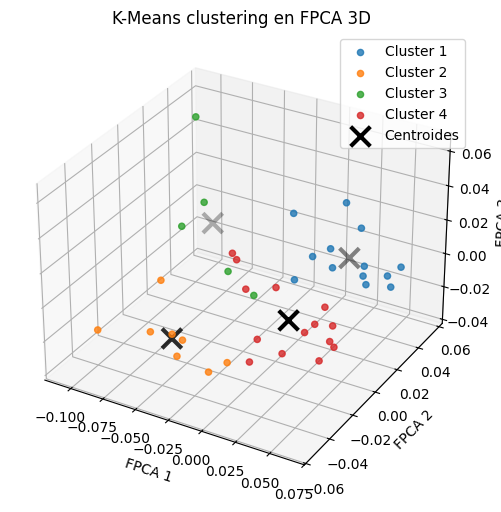

eps elegido automáticamente (DBSCAN 3D): 0.043
Clusters DBSCAN: [-1  0  1]


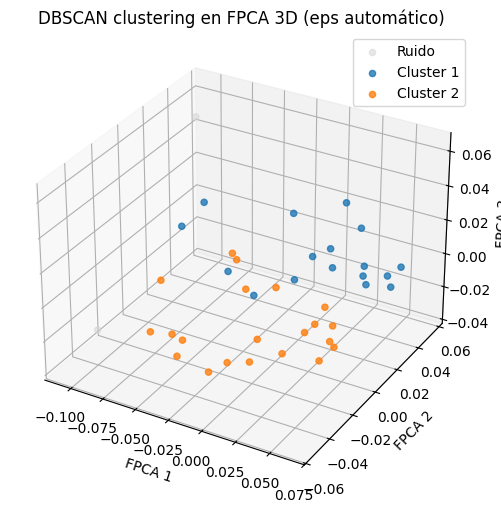

Clusters HDBSCAN: [-1  0  1  2]
Puntos por cluster: (array([-1,  0,  1,  2], dtype=int64), array([13, 13, 10,  4], dtype=int64))


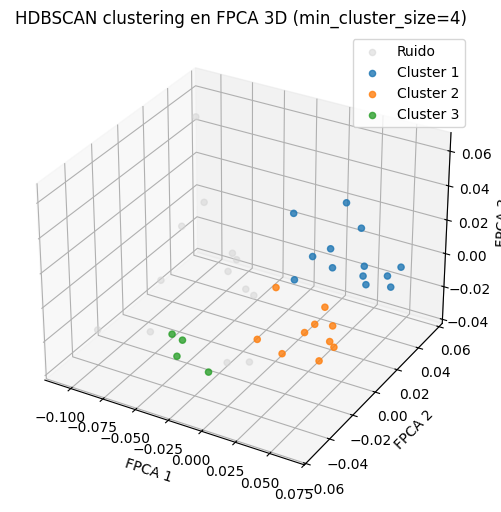

In [17]:
# CLUSTERING FPCA 3D

# ============================================================
# CLUSTERING FPCA 3D
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necesario para 3D
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import hdbscan

# ============================================================
# 1. SELECCIÓN AUTOMÁTICA DE K (SILHOUETTE)
# ============================================================

X = scores[:, :3]  # FPCA1, FPCA2, FPCA3

silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_tmp = km_tmp.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels_tmp))

n_clusters = K_range[np.argmax(silhouette_scores)]
print(f"Número óptimo de clusters (Silhouette): {n_clusters}")

# ============================================================
# 2. K-MEANS 3D
# ============================================================

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
labels_km = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
colors = plt.cm.tab10.colors

for k in range(n_clusters):
    ax.scatter(
        X[labels_km == k, 0],
        X[labels_km == k, 1],
        X[labels_km == k, 2],
        color=colors[k],
        alpha=0.8,
        label=f"Cluster {k+1}"
    )

ax.scatter(
    centroids[:, 0],
    centroids[:, 1],
    centroids[:, 2],
    marker="x",
    s=200,
    color="black",
    linewidths=3,
    label="Centroides"
)

ax.set_xlabel("FPCA 1")
ax.set_ylabel("FPCA 2")
ax.set_zlabel("FPCA 3")
ax.set_title("K-Means clustering en FPCA 3D")
ax.legend()
plt.show()

# ============================================================
# 3. DBSCAN 3D con eps automático
# ============================================================

min_samples = 3
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)
k_distances = np.sort(distances[:, min_samples - 1])
eps = k_distances[int(0.90 * len(k_distances))]
print(f"eps elegido automáticamente (DBSCAN 3D): {eps:.3f}")

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels_db = dbscan.fit_predict(X)
unique_db = np.unique(labels_db)
print("Clusters DBSCAN:", unique_db)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for lab in unique_db:
    if lab == -1:
        ax.scatter(
            X[labels_db == lab, 0],
            X[labels_db == lab, 1],
            X[labels_db == lab, 2],
            color="lightgray",
            alpha=0.5,
            label="Ruido"
        )
    else:
        ax.scatter(
            X[labels_db == lab, 0],
            X[labels_db == lab, 1],
            X[labels_db == lab, 2],
            alpha=0.8,
            label=f"Cluster {lab+1}"
        )

ax.set_xlabel("FPCA 1")
ax.set_ylabel("FPCA 2")
ax.set_zlabel("FPCA 3")
ax.set_title("DBSCAN clustering en FPCA 3D (eps automático)")
ax.legend()
plt.show()

# ============================================================
# 4. HDBSCAN 3D con parámetros heurísticos
# ============================================================

min_cluster_size = max(2, int(0.1 * X.shape[0]))
min_samples = 5

hdb = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
labels_hdb = hdb.fit_predict(X)
unique_hdb = np.unique(labels_hdb)
print("Clusters HDBSCAN:", unique_hdb)
print("Puntos por cluster:", np.unique(labels_hdb, return_counts=True))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for lab in unique_hdb:
    if lab == -1:
        ax.scatter(
            X[labels_hdb == lab, 0],
            X[labels_hdb == lab, 1],
            X[labels_hdb == lab, 2],
            color="lightgray",
            alpha=0.5,
            label="Ruido"
        )
    else:
        ax.scatter(
            X[labels_hdb == lab, 0],
            X[labels_hdb == lab, 1],
            X[labels_hdb == lab, 2],
            alpha=0.8,
            label=f"Cluster {lab+1}"
        )

ax.set_xlabel("FPCA 1")
ax.set_ylabel("FPCA 2")
ax.set_zlabel("FPCA 3")
ax.set_title(f"HDBSCAN clustering en FPCA 3D (min_cluster_size={min_cluster_size})")
ax.legend()
plt.show()
